# 動的重み付きアンサンブル: 共線形除去20特徴 × 乾物exp/quad加法 (LOSO) (2026-06-27)

[collinear_filtered_ensemble.md](../docs/collinear_filtered_ensemble.md) のアンサンブル(中低MCに強い, **cf**)と
[dry_band_exp_quad_model.md](../docs/dry_band_exp_quad_model.md) の exp/quad 加法(高MC外挿に強い, **dry**)の
**推論値を重み付き結合**して LOSO 検証する。特徴量は各モデルの定義をそのまま使い、結合は予測値レベルのみ。

**動的重み**: 推定MCが高いほど dry を重視 — `pred = (1-w)·cf + w·dry`,
`w = sigmoid((gate_MC - center)/scale)`。center/scale は LOSO macro-RMSE 最小で選択。

両モデル共通入力は `train_clean.csv`(dryをドキュメント通りの良好な形=ベイスギ外れ値除去後で使うため)。

In [1]:
import numpy as np, pandas as pd, warnings; warnings.filterwarnings('ignore')
import matplotlib, matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from scipy.optimize import curve_fit
from sklearn.base import clone
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from lightgbm import LGBMRegressor
matplotlib.rcParams['font.family']=['Hiragino Sans','AppleGothic','sans-serif']
matplotlib.rcParams['axes.unicode_minus']=False; matplotlib.rcParams['figure.dpi']=110

tr=pd.read_csv('../data/train_clean.csv',encoding='shift_jis')
META=['sample number','species number','樹種','含水率']
wn_cols=[c for c in tr.columns if c not in META]
wn=np.array([float(c) for c in wn_cols]); wl=1e7/wn; order=np.argsort(wl); nm=wl[order]
Xraw=tr[wn_cols].values.astype(float)[:,order]
y=tr['含水率'].values.astype(float); groups=tr['樹種'].values; species=np.unique(groups)
snv=lambda M:(M-M.mean(1,keepdims=True))/(M.std(1,keepdims=True)+1e-8)
sg =lambda M,d:savgol_filter(M,11,2,deriv=d,axis=1)
def fft_denoise(X,keep_frac=0.15):
    n=X.shape[1]; ifg=np.fft.fftshift(np.fft.ifft(X,axis=1),axes=1); c=n//2
    r=max(1,int(round(keep_frac*n/2))); ifg[:,:c-r]=0; ifg[:,c+r+1:]=0
    return np.fft.fft(np.fft.ifftshift(ifg,axes=1),axis=1).real
print('train_clean',tr.shape,'| 樹種',len(species),'| MC %.1f-%.1f%%'%(y.min(),y.max()))

train_clean (1270, 1559) | 樹種 13 | MC 0.8-298.6%


## モデル1 (cf): 共線形除去特徴 × LightGBM0.4 / SVR(rbf)0.3 / RF0.3

In [2]:
weak=fft_denoise(Xraw,0.15)
SRC={'snv_orig':snv(Xraw),'sg1_snv_orig':sg(snv(Xraw),1),'sg1_snv_weak':sg(snv(weak),1),
     'sg2_snv_weak':sg(snv(weak),2),'raw_weak':weak,'sg2_weak':sg(weak,2)}
BANDS={'snv_1430_1470':('snv_orig',(1430,1470)),'snv_sg1_2000_2100':('sg1_snv_orig',(2000,2100)),
       'snv_sg1_2400_2480':('sg1_snv_orig',(2400,2480)),'snv_sg1_1650_1670':('sg1_snv_weak',(1650,1670)),
       'snv_sg2_1910_1940':('sg2_snv_weak',(1910,1940)),'snv_sg1_2020_2100':('sg1_snv_weak',(2020,2100)),
       'raw_1050_1300':('raw_weak',(1050,1300)),'raw_sg2_1430_1470':('sg2_weak',(1430,1470)),
       'raw_sg2_1600_1700':('sg2_weak',(1600,1700))}
_slope=lambda B,w:(B*(w-w.mean())).sum(1)/((w-w.mean())**2).sum()
def _cr(B,w): t=(w-w[0])/(w[-1]-w[0]); line=B[:,[0]]*(1-t)[None]+B[:,[-1]]*t[None]; return (line-B).max(1)
STATS={'mean':lambda B,w:B.mean(1),'std':lambda B,w:B.std(1),'min':lambda B,w:B.min(1),
       'max':lambda B,w:B.max(1),'amp':lambda B,w:B.max(1)-B.min(1),
       'absmax':lambda B,w:np.abs(B).max(1),'slope':_slope,'cr_depth':_cr}
cols,names=[],[]
for bn,(src,(lo,hi)) in BANDS.items():
    m=(nm>=lo)&(nm<=hi); B,w=SRC[src][:,m],nm[m]
    for sn,f in STATS.items(): cols.append(f(B,w)); names.append(f'{bn}|{sn}')
F=pd.DataFrame(np.column_stack(cols),columns=names)
FINAL5=['snv_sg1_2000_2100|max','snv_sg1_2020_2100|cr_depth','raw_sg2_1430_1470|min',
        'snv_1430_1470|slope','snv_sg1_2000_2100|cr_depth']
CORR_TH=0.90; MC_TH=0.30
corr=F.corr().fillna(0); absmc=F.corrwith(pd.Series(y,index=F.index)).abs().fillna(0)
hp=corr.where(np.triu(np.ones(corr.shape,bool),1)).abs().stack(); hp=hp[hp>=CORR_TH].sort_values(ascending=False)
keep_key=lambda f:(f in FINAL5,absmc[f]); dropped=set()
for (a,b),v in hp.items():
    if a in dropped or b in dropped: continue
    dropped.add(a if keep_key(a)<keep_key(b) else b)
after=[c for c in F.columns if c not in dropped]
DROP=['raw_sg2_1430_1470|cr_depth','raw_1050_1300|slope','raw_1050_1300|absmax']
SEL=[c for c in after if absmc[c]>MC_TH and c not in DROP]
Xf=F[SEL].values
CF_MODELS={'LightGBM':LGBMRegressor(n_estimators=400,learning_rate=0.05,random_state=0,verbose=-1),
           'SVR(rbf)':make_pipeline(StandardScaler(),SVR(kernel='rbf',C=10,gamma='scale')),
           'RandomForest':RandomForestRegressor(n_estimators=400,random_state=0,n_jobs=-1)}
CF_W={'LightGBM':0.4,'SVR(rbf)':0.3,'RandomForest':0.3}
def loso_oof(model,X):
    oof=np.zeros(len(y))
    for s in species:
        te=groups==s; oof[te]=np.ravel(clone(model).fit(X[~te],y[~te]).predict(X[te]))
    return oof
cf_oof={m:loso_oof(md,Xf) for m,md in CF_MODELS.items()}
pred_cf=sum(CF_W[m]*cf_oof[m] for m in CF_MODELS)
print('cf 特徴数',len(SEL),'| OOF完了')

cf 特徴数 22 | OOF完了


## モデル2 (dry): 乾物5バンド × exp/quad 加法 (w_exp=0.9)

In [3]:
S,S1,S2=snv(Xraw),sg(snv(Xraw),1),sg(snv(Xraw),2)
bd=lambda M,lo,hi:M[:,(nm>=lo)&(nm<=hi)].mean(1)
Fdry=np.column_stack([bd(S1,1260,1300),bd(S2,1700,1740),bd(S2,2300,2340),bd(S2,2200,2240),bd(S,2340,2400)])
CLIP=20.0
class Std:
    def fit(self,X): self.mu=X.mean(0); self.sd=X.std(0)+1e-9; return self
    def z(self,X): return (X-self.mu)/self.sd
quad_basis=lambda Z:np.hstack([Z,Z**2])
def fit_expB(Z,yy):
    B=[]
    for j in range(Z.shape[1]):
        try:
            p,_=curve_fit(lambda x,A,Bj,C:A*np.exp(np.clip(Bj*x,-CLIP,CLIP))+C,Z[:,j],yy,
                          p0=[yy.std(),0.5,yy.mean()],maxfev=20000); B.append(np.clip(p[1],-3,3))
        except Exception: B.append(0.3)
    return np.array(B)
exp_basis=lambda Z,B:np.exp(np.clip(Z*B,-CLIP,CLIP))
class AddRidge:
    def __init__(self,basis='exp',alpha=1.0): self.basis=basis; self.alpha=alpha
    def _phi(self,Z): return exp_basis(Z,self.B) if self.basis=='exp' else quad_basis(Z)
    def fit(self,X,yy):
        self.s=Std().fit(X); Z=self.s.z(X)
        if self.basis=='exp': self.B=fit_expB(Z,yy)
        P=self._phi(Z); self.ps=Std().fit(P); self.m=Ridge(self.alpha).fit(self.ps.z(P),yy); return self
    def predict(self,X):
        Z=self.s.z(X); return np.clip(self.m.predict(self.ps.z(self._phi(Z))),0,400)
def oof_dry(mf):
    p=np.zeros(len(y))
    for s in species:
        te=groups==s; p[te]=mf().fit(Fdry[~te],y[~te]).predict(Fdry[te])
    return p
Pexp=oof_dry(lambda:AddRidge('exp')); Pquad=oof_dry(lambda:AddRidge('quad'))
W_EXP=0.9; pred_dry=W_EXP*Pexp+(1-W_EXP)*Pquad
print('dry OOF完了')

dry OOF完了


## 動的重み付け結合

推定MC(ゲート信号)が高いほど dry を重視。ゲート信号は `cf` / 両者平均 / 両者max を候補に、
center・scale を LOSO macro-RMSE 最小でグリッド選択。

In [4]:
def per_species_rmse(p): return {s:np.sqrt(np.mean((p[groups==s]-y[groups==s])**2)) for s in species}
def overall_rmse(p): return np.sqrt(np.mean((p-y)**2))
def macro(p): return np.mean(list(per_species_rmse(p).values()))
sigmoid=lambda x:1/(1+np.exp(-x))
def dyn_pred(gate,c,s): w=sigmoid((gate-c)/s); return (1-w)*pred_cf+w*pred_dry
GATES={'cf':pred_cf,'mean':0.5*(pred_cf+pred_dry),'max':np.maximum(pred_cf,pred_dry)}
best=None
for gn,g in GATES.items():
    for c in range(60,201,5):
        for s in [5,8,10,15,20,30,40]:
            mm=macro(dyn_pred(g,c,s))
            if best is None or mm<best[0]: best=(mm,gn,c,s)
bm,bg,bc,bs=best; gate=GATES[bg]; pred_dyn=dyn_pred(gate,bc,bs)
print('動的重み最良: gate=%s center=%d scale=%d  macro=%.2f'%(bg,bc,bs,bm))
print('cf       : overall %.2f  macro %.2f'%(overall_rmse(pred_cf),macro(pred_cf)))
print('dry      : overall %.2f  macro %.2f'%(overall_rmse(pred_dry),macro(pred_dry)))
print('動的ens  : overall %.2f  macro %.2f'%(overall_rmse(pred_dyn),macro(pred_dyn)))
r1=per_species_rmse(pred_cf); r2=per_species_rmse(pred_dry); rd=per_species_rmse(pred_dyn)
tbl=pd.DataFrame({'cf':r1,'dry':r2,'動的ens':rd}); tbl['平均MC']=[y[groups==s].mean() for s in tbl.index]
display(tbl.sort_values('平均MC').round(1))

動的重み最良: gate=max center=190 scale=5  macro=17.37
cf       : overall 22.41  macro 18.50
dry      : overall 27.51  macro 25.86
動的ens  : overall 20.08  macro 17.37


,cf,dry,動的ens,平均MC
ウエンジ,23.9,5.2,23.9,15.5
トチ,10.7,7.8,10.7,31.6
ホワイトオーク,18.3,21.4,18.4,33.4
スプルース,6.9,28.2,7.0,37.1
ヒノキ,11.1,29.5,11.0,39.6
ナラ,7.5,11.4,7.5,41.8
ベイマツ,5.0,23.1,5.2,41.8
チェリー,24.8,25.0,24.9,53.4
ウォールナット,12.7,39.9,12.7,57.2
米ヒバ,13.2,25.3,13.2,70.1


## 図1: 動的重み曲線 と 樹種別RMSE比較

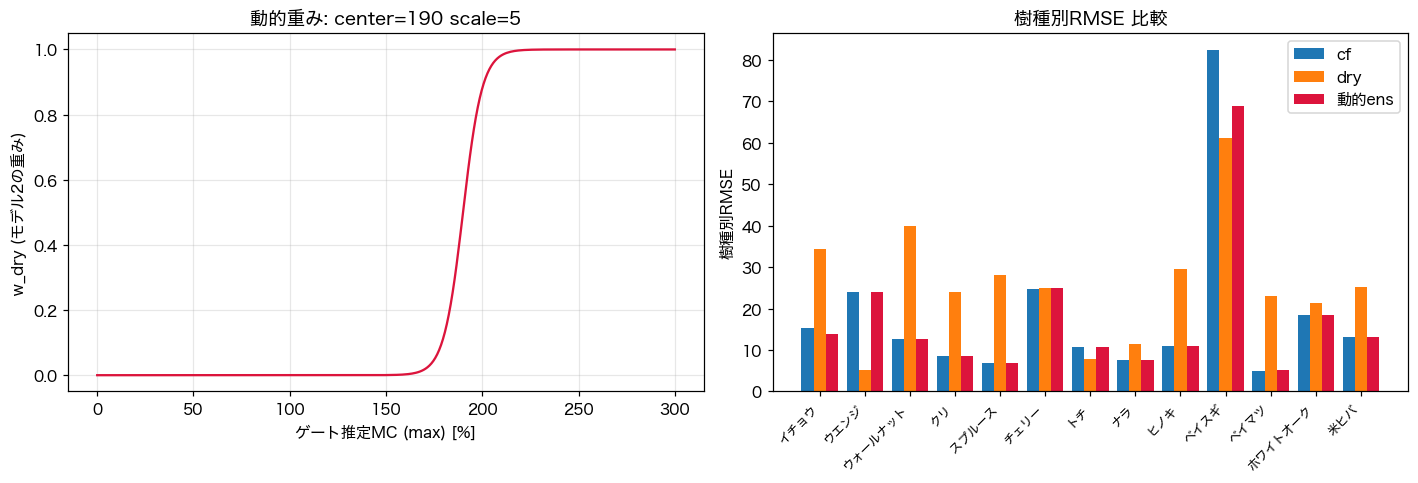

In [5]:
fig,ax=plt.subplots(1,2,figsize=(13,4.5))
gg=np.linspace(0,300,300); ax[0].plot(gg,sigmoid((gg-bc)/bs),color='crimson')
ax[0].set_xlabel('ゲート推定MC (%s) [%%]'%bg); ax[0].set_ylabel('w_dry (モデル2の重み)')
ax[0].set_title('動的重み: center=%d scale=%d'%(bc,bs)); ax[0].grid(alpha=.3)
sp_x=np.arange(len(species)); ax[1].bar(sp_x-0.27,[r1[s] for s in species],0.27,label='cf')
ax[1].bar(sp_x,[r2[s] for s in species],0.27,label='dry')
ax[1].bar(sp_x+0.27,[rd[s] for s in species],0.27,label='動的ens',color='crimson')
ax[1].set_xticks(sp_x); ax[1].set_xticklabels(species,rotation=45,ha='right',fontsize=8)
ax[1].set_ylabel('樹種別RMSE'); ax[1].set_title('樹種別RMSE 比較'); ax[1].legend()
plt.tight_layout(); plt.show()

## 図2: 樹種別 真値 vs LOSO予測(横軸=樹種内サンプル番号 0始まり)

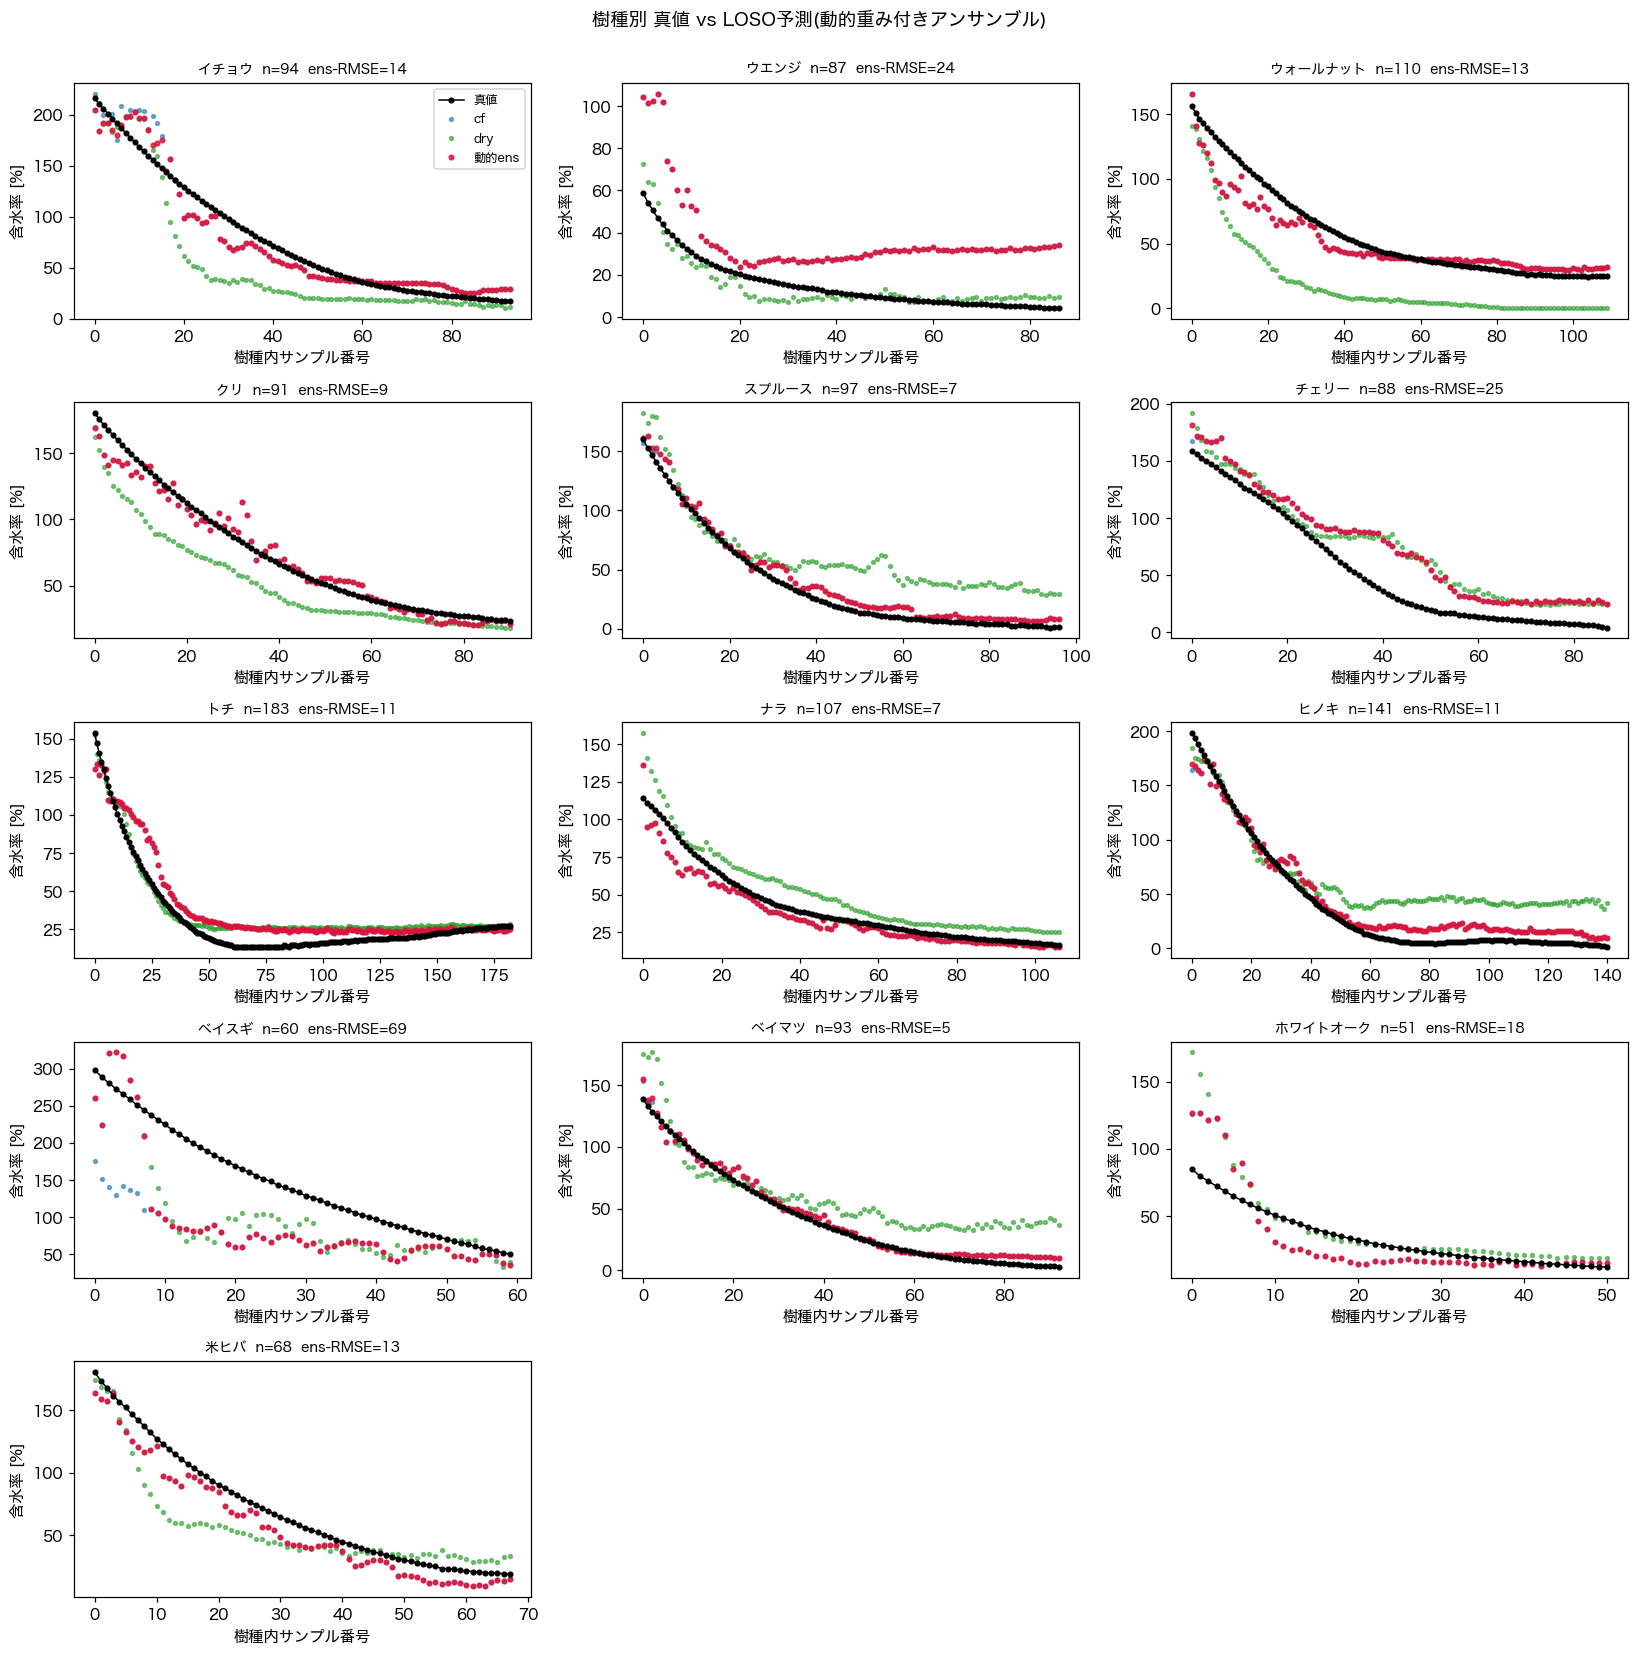

In [6]:
ncol=3; nrow=int(np.ceil(len(species)/ncol))
fig,ax=plt.subplots(nrow,ncol,figsize=(15,3.0*nrow)); ax=ax.ravel()
for i,s in enumerate(species):
    m=np.where(groups==s)[0]; x=np.arange(len(m)); a=ax[i]
    a.plot(x,y[m],'-o',color='k',ms=3,lw=1,label='真値',zorder=3)
    a.plot(x,pred_cf[m],'.',color='tab:blue',ms=5,alpha=.6,label='cf')
    a.plot(x,pred_dry[m],'.',color='tab:green',ms=5,alpha=.6,label='dry')
    a.plot(x,pred_dyn[m],'.',color='crimson',ms=6,alpha=.85,label='動的ens')
    a.set_title('%s  n=%d  ens-RMSE=%.0f'%(s,len(m),rd[s]),fontsize=9)
    a.set_xlabel('樹種内サンプル番号'); a.set_ylabel('含水率 [%]')
for j in range(len(species),len(ax)): ax[j].axis('off')
ax[0].legend(fontsize=8)
plt.suptitle('樹種別 真値 vs LOSO予測(動的重み付きアンサンブル)',y=1.0)
plt.tight_layout(); plt.show()

## まとめ・注意

- **動的アンサンブルは cf 単独より macro / overall とも改善**し、改善はほぼ全て**高MCのベイスギ**に集中
  (中低MC樹種は cf 値を維持)。これは「高MCほど dry を重視」という設計通りの挙動。
- ゲートは高MC側で鋭く切り替わる解が選ばれる(ベイスギのみ dry に寄せるのが macro 的に最適なため)。
  より滑らかな運用にしたい場合は center/scale を手動で緩める。
- **リーク注意**: cf の特徴選択・dry のバンド選定・本notebookの center/scale はいずれも全fold集計で固定=楽観値。
  厳密な外挿見積りには fold 内で全選択を行うネストLOSOが必要。
- 共通入力は `train_clean.csv`(ベイスギ外れ値除去後)。dry をドキュメント通りの形で使うため。